# Continuation of an equilibrium solution

2025-11-04. Continue an ODE equilibrium solution using BifurcationKit, compare to DNS

## 0. Preliminaries

In [1]:
using LinearAlgebra, Polynomials, Plots, DelimitedFiles, BenchmarkTools, Revise
import BifurcationKit as BK

using CloudAtlas

#display("text/html", "<style>.container { width:100% !important; }</style>")

"""
    myreaddlm(filename, cc='%')

Read matrix or vector from a file, dropping comments marked with cc.
"""
function myreaddlm(filename; cc='%')
    X = readdlm(filename, comments=true, comment_char=cc)
    if size(X,2) == 1
        X = X[:,1]
    end
    X
end

sx, sy, sz, tx, tz = halfbox_symmetries()

pwd()

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks"

## 1. Construct ODE model, find equilibrium solution.

This repeats some code from notebook `find-ode-eqb.ipynb`.

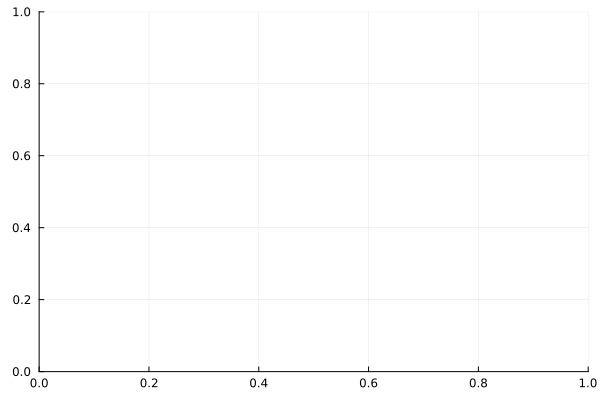

In [2]:
plot()

In [3]:
α, γ = 1.0, 2.0                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
J,K,L = 2,2,3  #1,2,3  #1,1,3                 # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb

model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 

@show m = length(model);            # dimension of ODE model

J,K,L,m == 2,2,3,44
(2J+1)(2K+1)(2L+1) + 1 == 176
Making matrices B,A1,A2,S3...
Making quadratic operator N...
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 
m = length(model) = 44


Load initial guesses for EQ1 (lower branch) and EQ2 (upper branch) from
files. These are computed by projecting DNS solutions onto the basis, using channelflow. 

In [4]:
xguess = myreaddlm("data/xeq1projection-Re200-2-2-3-44d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc

R = 200
#x = zeros(m)
@show norm(model.f(xguess, R)); #x, R

norm(model.f(xguess, R)) = 0.00991549981572763


Find the ODE representations of the lower and upper branch solutions.

In [5]:
fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

@time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

@show norm(fr(xeq1))/norm(xeq1);

  1.053161 seconds (1.80 M allocations: 96.567 MiB, 3.04% gc time, 97.91% compilation time)
norm(fr(xeq1)) / norm(xeq1) = 8.658029169686263e-13


## 2. Continuation of eqbs with BifurcationKit



Compute bifurcation diagram from xeq1 solution.

In [6]:
shear(xeq1, model)

1.7954971498789152

In [7]:
myshear = x -> shear(x,model)
myshear(xeq1)

1.7954971498789152

(J, K, L, m, R) = (2, 2, 3, 44, 200)


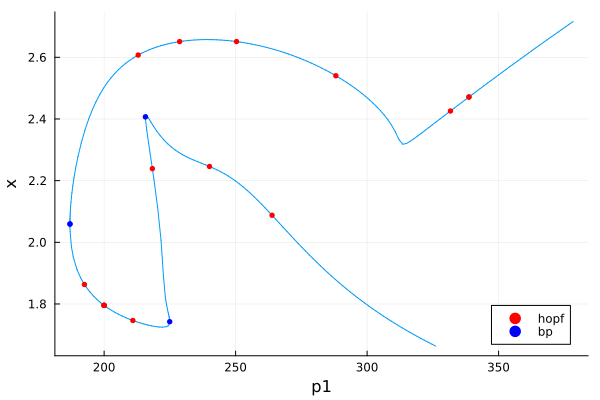

In [8]:
@show J, K, L, m, R

fp(x,p) = model.f(x,p[1])
prob1 = BK.BifurcationProblem(fp,
        xeq1,         # initial condition x0
        [Float64(R)], # set of parameters
        1;            # parameter index for continuation
        #record_from_solution = (x,p; k...) -> shear(x),
        plot_solution = (x,p; k...) -> myshear(x),
        record_from_solution = (x,p; k...) -> myshear(x),
    )

newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, #Ask Gibson why dsmin was set to 1e-07
    max_steps = 200, newton_options = newtopts)

br1 = false
try
    br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)  #Ask Gibson what this does besides throw errors
    plot!(br1)
catch e
    println(e)
end


Compute bifurcation diagram from xeq2 solution. For some reason BifurcationKit doesn't go around the saddle-node bifurcation. I need to learn how to tune the algorithm.

Plot the ODE bifurcation diagram along with the DNS.

163.5222 : 187.01559068553055

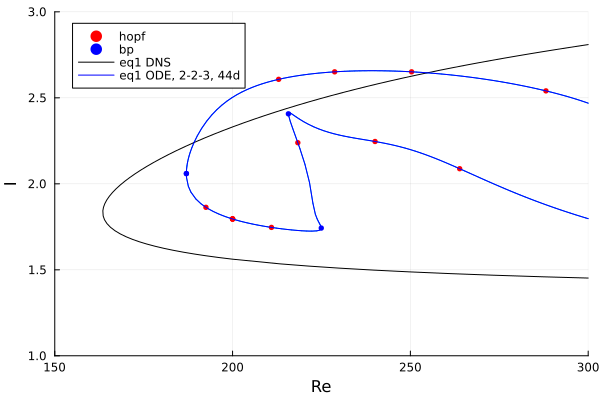

In [9]:
ReD1 = [br1.param br1.x];

eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
#@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq1 DNS")
plot!(ReD1[:,1], ReD1[:,2], color=:blue, label="eq1 ODE, $J-$K-$L, $(m)d")
#plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))

In [10]:
minDNS = false
parameters = []
minimums = []
AYErrors = []
jask = []


Any[]

In [2]:
function DataTable(a, y, r, n, c, fs)#, na, ny)
    #vectorTable = []
    α, γ = a, y                     # Fourier wavenumbers α, γ = 2π/Lx, 2π/Lz
    J,K,L = 1,2,3  #1,2,3  #1,1,3      # Bounds on Fourier modes (J,K) and wall-normal polynomials (L)
    H = [sx*sy*sz, sz*tx*tz]            # Generators of the symmetric subspace of the Nagata eqb

    try
        model = ODEModel(α, γ, J, K, L, H)  # Construct ODE model by Galerkin projection 
        
        ###@show m = length(model);            # dimension of ODE model
        ##################
        xguess = myreaddlm("data/xeq1projection-Re200-1-2-3-27d.asc") #data/xeq1projection-Re200-1-2-3-27d.asc

        R = r
        ###@show norm(model.f(xguess, R));
        ##################
        fr = x -> model.f(x,R)    # define function  f(x) = f(x,R)  for fixed R
        Dfr = x -> model.Df(x,R)  # define function Df(x) = Df(x,R) for fixed R

        @time xeq1, eq1success = hookstepsolve(fr, Dfr, xguess)

        ###@show norm(fr(xeq1))/norm(xeq1);
        ##################
        shear(xeq1, model)
        ##################
        myshear = x -> shear(x,model)
        myshear(xeq1)
        ##################
        ###@show J, K, L, m, R

        fp(x,p) = model.f(x,p[1])
        prob1 = BK.BifurcationProblem(fp,
            xeq1,         # initial condition x0
            [Float64(R)], # set of parameters
            1;            # parameter index for continuation
            #record_from_solution = (x,p; k...) -> shear(x),
            plot_solution = (x,p; k...) -> myshear(x),
            record_from_solution = (x,p; k...) -> myshear(x),
        )

        newtopts = BK.NewtonPar(1e-10, 25, false, BK.DefaultLS(), BK.DefaultEig(), false, 1.0, 0.01)
        contopts = BK.ContinuationPar(p_min = 0., p_max = 400., n_inversion=20, dsmin=1e-12, dsmax=1.0, 
            max_steps = 600, newton_options = newtopts)
        ### contopts = BK.ContinuationPar(p_min = 100., p_max = 400., n_inversion=20, dsmin=1e-07, dsmax=1.0, 
        ###    max_steps = 200, newton_options = newtopts)

        br1 = BK.continuation(prob1, BK.PALC(), contopts, bothside=true)

        ###plot!(br1, legendfontsize=fs)
        ##################
        ReD1 = [br1.param br1.x];

        #@show minimum(eq1ReD[:,1]), minimum(ReD1[:,1])
        #print(minimum(eq1ReD[:,1]), " : ", minimum(ReD1[:,1]))
        plot!(ReD1[:,1], ReD1[:,2], color=c, label="", legendfontsize=fs)###"eq$n ODE, $J-$K-$L, $(m)d, $α x $γ", legendfontsize=fs)
        #plot!(ReD2[:,1], ReD2[:,2], color=:blue, label="")
        plot!(xlabel="Re", ylabel="I", xlim=(150,300), ylim=(1,3))
        ##################
        if minimum(ReD1[:,1]) > 1
            push!(parameters, [α, γ])
            push!(minimums, [minimum(ReD1[:,1])])
            #=if (na > size(matrix, 1))
                push!(matrix, [])
            end
            push!(matrix[na], [minimum(ReD1[:,1])])=#
            push!(matrix, minimum(ReD1[:,1]))
        else
            push!(AYErrors, [α, γ, r])
            #=if (na > size(matrix, 1))
                push!(matrix, [])
            end
            push!(matrix[na], [0])=#
            push!(matrix, 0)
        end
        #return [br1, ReD1, c, n, J, K, L, m, α, γ]
        #return [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])]
        #push!(vectorTable, [minimum(eq1ReD[:,1]), minimum(ReD1[:,1])])
        #return vectorTable
    catch e
        push!(AYErrors, [α, γ, r])
        push!(matrix, 0)
    end
end

DataTable (generic function with 1 method)

In [3]:
using Suppressor

parameters = []
minimums = []
AYErrors = []
matrix = []

Any[]

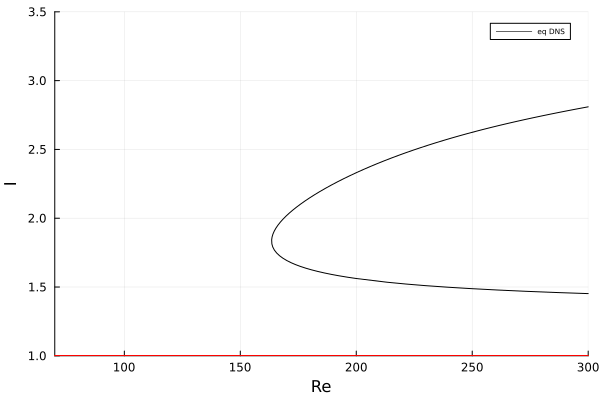

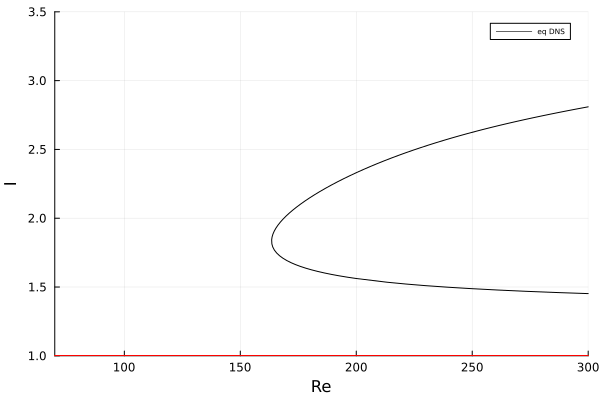

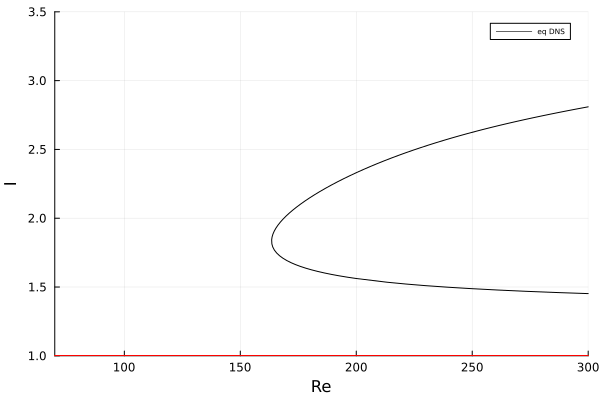

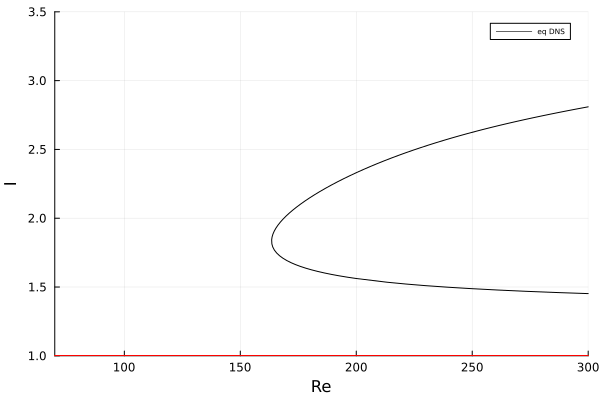

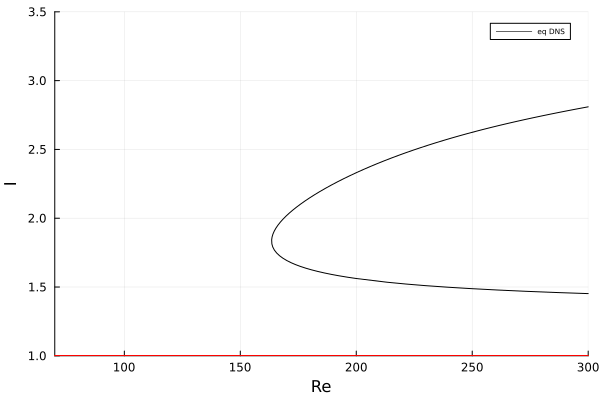

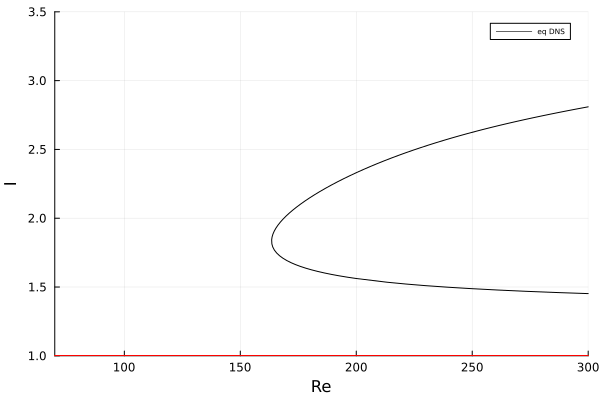

26-element Vector{Float64}:
 6.0974087033179425e-6
 8.248214702306706e-5
 4.952206569287912e-5
 0.0004300557730478392
 0.0001210443338131183
 5.0200675207708796e-5
 0.00029691398108034565
 8.857055138378465e-5
 4.843408551949642e-5
 0.0016502367173464622
 ⋮
 0.009517411678231653
 0.0023914336229101506
 0.0006101246896559529
 0.0001655790388327179
 5.833263780116167e-5
 8.296075447010582e-5
 4.93268494399859e-5
 0.0004873503247655775
 0.00013517282208803035

26-element Vector{Float64}:
 3.451868938050505e-5
 0.4253275277948777
 0.10627342197457744
 0.026513167421591342
 0.006823505752337498
 0.001811149752363611
 0.0005506125186573132
 0.00032584158857405825
 0.0024715243029795617
 0.0007097416438071457
 ⋮
 0.0012353614259020278
 0.00041614661446347614
 0.0004435902746230451
 0.00039340661562467836
 0.0005168592830840729
 0.00033677027203310895
 0.0015558478603858285
 0.0004891012144475339
 0.00035064975331576727

26-element Vector{Float64}:
 6.109077803883992e-5
 1.7070301257003362
 0.4269682932324648
 0.10699565551099163
 0.026493579109423192
 0.0071645817745822
 0.001817253197681897
 0.0007044439157487638
 0.0013811812669586511
 0.0006185196241826399
 ⋮
 0.0007851450126019592
 0.0008797906939275522
 0.0007171848821208756
 0.0011994065764139605
 0.0006101537398100058
 0.519981294480503
 0.1301479964033107
 0.032690210857534804
 0.008327945922004323

26-element Vector{Float64}:
   0.00011697124777204362
 480.49835305013977
 120.12459443617703
  30.03116281582633
   7.507826418498713
   1.8770909604517931
   0.46635597651158944
   0.11866388688444984
   0.030243244445615547
   0.009014383747080992
   ⋮
   0.001506971510219233
   0.0023195139258052034
   0.001272057425643533
   0.040818272413829966
   0.010530174364912858
   0.0029910494548249004
   0.0012936433372678713
   0.013279708746749976
   0.003668600574413609

26-element Vector{Float64}:
 0.0003105552540371817
 0.8555826984270619
 0.21391582651284505
 0.053856861335948754
 0.01659397949486876
 0.005023332392623502
 0.01814997492365877
 0.006401558261471785
 0.015383000261220206
 0.0050642564532759286
 ⋮
 0.009048160922216822
 0.003969779287293913
 0.05049429256911879
 0.013677261732633707
 0.004777098989309698
 0.006416977011801838
 0.004069861814728903
 0.022707294609587477
 0.006849441554678089

26-element Vector{Float64}:
   0.00034010395630088
   6.972592404152161
   1.743138796809018
   0.4357939344616915
   0.10926215931185244
   0.02906769572927402
   0.008755055141083724
   0.0041374033110260005
   0.06441194372227288
   0.01685290484239977
   ⋮
   0.2967264189803319
   0.07531378439400431
   0.020140402614426678
   0.006292353110962797
   0.0052848150336835395
   0.008946581928899681
   0.004459580619856062
 141.72771763026546
  35.43304432208891

26-element Vector{Float64}:
 0.0004004985683673074
 1.945322567605626
 0.4863406802522914
 0.12179655320952937
 0.032490491737359004
 0.011285623643487171
 0.006146283615411315
 0.013213494683940768
 0.011810270692615258
 0.07355682109423818
 ⋮
 0.0057748616009056074
 3.721167289212958
 0.9317383685438514
 0.23439151435391178
 0.06009458751102968
 0.01671307725733663
 0.006120865960948937
 0.018030790134281712
 0.00666369270025279

26-element Vector{Float64}:
 0.00042690038219781525
 2.2515475023088567
 0.5628966456757271
 0.1409141608364486
 0.03711507206154061
 0.025078952766651726
 0.03431793714851444
 0.22593777081749283
 0.0552232392661421
 0.21579293934526944
 ⋮
 0.12212118252114686
 0.03246449571981087
 0.011181569580046164
 0.007744102874708503
 0.020922860991143682
 0.006985997993901113
 0.01456348664047385
 0.006698761185921501
 0.5470387570127891

26-element Vector{Float64}:
   0.00045022429773021564
   3.089569079100835
   0.7724005270953623
   0.19322590125410394
   0.04778708099634526
   0.29199829149808404
   0.12238702755254613
   0.0335844894870739
   0.031450846131098276
   0.008979708831063735
   ⋮
   0.43517597018431925
   0.3079106336636653
   1.1227630835784759
  44.12635003675229
  11.126439750330684
 300.02373511108505
  75.11205235063858
  22.803920520301318
   6.812315671069443

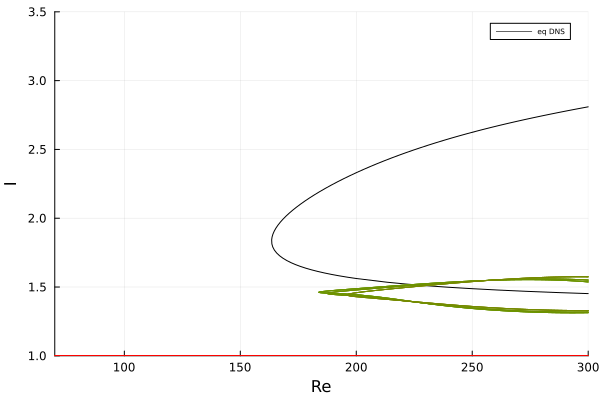

26-element Vector{Float64}:
   0.00046435844304266327
  52.30134104596921
  13.07533117416006
   3.2688748207477345
   0.8174869400887803
   0.2064204102303046
   5.261664911698134
   1.3150326349080892
  23.382007371910802
   6.889124577960017
   ⋮
  21.090450462123936
 920.5721661735492
 224.11586541581255
  56.18707337219617
  14.153911420760325
  46.71863473503732
  24.602961667114553
  31.62025407727305
   7.708654464512346

26-element Vector{Float64}:
  0.00045423178550460383
 26.04475465596816
  6.511242090920842
  1.6280605639659507
  0.4105773165927263
  0.10647673587152079
  5.921648401655368
  1.4994930916908646
  0.4059184832593477
  0.49120809324297793
  ⋮
  0.20477425848598402
  9.870168704712086
  2.566180191785165
  0.6440305458320352
  0.6245263569564206
  0.19359802988495806
  0.37052541652229065
  8.580383196061796
  2.309867831048161

26-element Vector{Float64}:
 5.470506877058134e-5
 0.0009201702689369862
 0.00029662355685753614
 0.0002556919866403844
 0.0003600122405056495
 0.00021651561042567355
 0.0019021874081881064
 0.0005346732185010474
 0.00022036388155947028
 0.0012124657357407607
 ⋮
 0.3119425540652862
 0.07803826179361638
 0.019562295373277076
 0.004943733252502432
 0.0012908581029329905
 0.00038554001555611366
 0.0002121155337866359
 0.006375237168370391
 0.0016481914244224178

26-element Vector{Float64}:
   6.296865193024934e-5
 443.9446926658308
 110.98617095003088
  27.746532832307665
   6.936607347774425
   1.734090728417681
   0.43350171775604135
   0.10768129662600161
   0.028726877686042724
   0.007316797465950283
   ⋮
   0.0005539882208379288
   0.003280116165299035
   0.0009782773646628206
   0.0005344369590953174
   0.018597810725235867
   0.004785997674693071
   0.0013456886026995145
   0.0005554219295275619
   0.0031067573222947073

26-element Vector{Float64}:
 8.302280533126122e-5
 1.7248896700084715
 0.43113015560969375
 0.10735805097821326
 0.027628728552293123
 0.007550520935902519
 0.0021812343129831453
 0.0009596786899093289
 0.011139568540198649
 0.0030297805109808806
 ⋮
 0.061847639254813506
 0.015683690705977853
 0.004152479626015375
 0.0013151003658357493
 0.0009814937684061882
 0.0022524974437564656
 0.0009205430450868814
 0.004608713915836401
 0.0014220312254322682

...

26-element Vector{Float64}:
 0.0003814927830944511
 2.044936683452223
 0.5112542548445604
 0.12790380734670356
 0.03411969175402656
 0.01123052593257378
 0.004278136580984635
 0.0379338316324865
 0.014652564109828558
 0.006485454419754512
 ⋮
 0.006292268061838698
 0.012551469653117868
 0.005377755992570448
 0.044073637169575325
 0.012351938787905893
 0.0055803818800076324
 0.060235292265486344
 0.016530648460143262
 0.006104763784375165

26-element Vector{Float64}:
   0.00041541375120662756
   0.42775502596714204
   0.10694508651249501
   0.02709637747421223
   0.00939477031513414
   0.008737232141459593
   0.0070511698623431755
   0.02921111212836361
   0.009292382366844562
   0.006942158841583768
   ⋮
 110.01125424077863
  27.50435383076105
   6.877624787457729
   1.7209464008577688
   0.431779829056232
   0.10950130904096102
   0.02899365338232415
   0.009125691178538878
   0.006799742733473876

26-element Vector{Float64}:
     0.00044229516109941386
     2.1193556735471453
     0.5298550772748382
     0.13245763904906016
     0.03701868503676512
     0.054476691013239834
     0.18270756360599172
     0.055876148760842105
    11.371605687328264
     2.851160663689552
     ⋮
     0.3089608870585787
 46117.42336061715
 11529.38690243313
  2882.3831971711593
   720.6381556529623
   180.20481363175813
    45.0855883037191
    10.456197918778914
     2.484453761155313

26-element Vector{Float64}:
    0.0004930844060395575
 1032.1694049478072
  258.0423415474303
   64.51055891737761
   16.127538161077602
    4.032117124881178
    1.0079625297517236
    0.2525794041608694
    0.06299899328459976
    0.15673817334602294
    ⋮
    1.2610348298804692
    0.7367581348151512
    6.075853912508435
    1.5616071754410348
    7.134566165382791
   10.84928374244238
    3.4780113413423317
    0.8268032499750277
    2.9443796059614167

26-element Vector{Float64}:
   0.0004998541172390858
 175.32359062887403
  43.83091453237538
  10.957781566550963
   2.739593091409582
   0.6854323136066538
   0.18669414008254467
   0.04901075374912955
   0.016249107156399947
   0.0073600647839855106
   ⋮
   0.0016120358083206972
   0.003387713374603932
   0.0014356353021457427
   0.005932867739219822
   0.0018993029108639347
   0.001511238063176968
   0.002732432407669152
   0.0013042952617558544
   0.14573672064582552

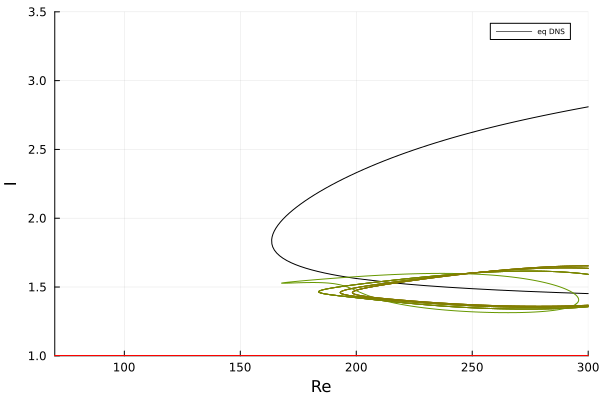

26-element Vector{Float64}:
 3.171157141451651e-5
 0.0016799177835535245
 0.0004974830545906029
 0.00023752714615015574
 0.08234064481523913
 0.02064478244870128
 0.005221454791335962
 0.0013677785702852644
 0.00041413004433664706
 0.00024401920157165658
 ⋮
 0.0002700075452350224
 0.0005770338720868241
 0.00024583303559203105
 0.0020386024591030425
 0.0005771504196379659
 0.00024584773201942434
 0.0020348111696320073
 0.0005762192583252559
 0.00024573059255223053

26-element Vector{Float64}:
 5.192857426934663e-6
 0.008896284554831017
 0.0022324674537120156
 0.0005682607022909123
 0.00015282646621631214
 5.2274193133757415e-5
 6.147211922424996e-5
 4.650701827936129e-5
 0.00010110437220163003
 4.263076132027706e-5
 ⋮
 9.406919551310956e-5
 4.181135237616564e-5
 0.000669794837309851
 0.0001784121209530931
 5.797836929171971e-5
 4.996412029702279e-5
 7.087832902195043e-5
 4.225962681643165e-5
 0.000405591976704983

26-element Vector{Float64}:
 2.714433182415468e-5
 0.24937163843383078
 0.06268032732385559
 0.01576803963596318
 0.003833160161231898
 0.0011717069784587817
 0.0003551761267423363
 0.0004055543996241266
 0.00033308421896572737
 0.0005436715966265675
 ⋮
 0.0002880238645691145
 0.003519147337855272
 0.0009564669264474198
 0.00033915899227791066
 0.0005042607718321751
 0.00028618227379013234
 0.005053424820604999
 0.0013380594959016001
 0.00042389292012561875

26-element Vector{Float64}:
 6.041053789929417e-5
 0.4345417770519115
 0.10817500949782552
 0.027780033285638266
 0.007081819623042704
 0.002062575755974715
 0.0007385713242773828
 0.001584762123351798
 0.0006667359049341414
 0.00439730796063486
 ⋮
 0.5369376255656995
 0.13439552671319652
 0.03376058132696687
 0.008604194756233302
 0.002324977974171547
 0.000803764522252588
 0.001008793746860308
 0.0006967811126892126
 0.002285019454609724

26-element Vector{Float64}:
  9.437426269186522e-5
 29.6062304150577
  7.401587024771173
  1.850361777988273
  0.462575287349209
  0.11561208657160077
  0.029567643868318862
  0.00753865210260319
  0.002153642467221566
  0.0010319189457499206
  ⋮
  0.0011824882518177782
  0.0022942133478806213
  0.0010409027961327138
  0.02499475631706932
  0.0065172721308330754
  0.001935174180515469
  0.0010343770848921174
  0.06202549806251135
  0.015768239571684706

...

26-element Vector{Float64}:
   0.0004320313531016552
   2.4682296083333592
   0.617094304538169
   0.15429730965794525
   0.03957455642660693
   1.1904324246875613
   0.295466704254386
   0.14389114994634994
   0.06954800359511129
 780.7523277774673
   ⋮
   2.3800680555901406
   0.8074936198944658
   4.787420408781335
   3.016725389079664
   0.796044148338547
   0.35738657245989086
   2.631325521883182
   0.7411901376689441
   1.1856130541873853

26-element Vector{Float64}:
  0.00045834383152307376
  4.145769427521013
  1.0364671804071688
  0.25918584547244056
  0.06401840570557836
  0.10257474552606127
  1.591748438449556
  0.3622932738251356
  0.3792009469008968
  0.2399039212878541
  ⋮
  1.6107006705484606
 11.525608344919842
  2.8483917798794534
  1.189234474040221
 15.60775876461596
  4.055832784344668
  1.0053469314541321
  0.6937890164642716
  0.4467632767660277

26-element Vector{Float64}:
  0.00048245720540982136
 29.137682953033586
  7.284425556664347
  1.82113196515118
  0.4553344817469261
  0.11350714927492692
  0.03477695865780344
  0.4912686798245516
  0.12049745479884606
  0.04077854262411138
  ⋮
  0.07212907518709448
  0.019464518985348546
  0.0194886279267022
  0.00648539807613764
  0.0026395003599542473
  0.0017007069252627743
  0.00042943070319668297
  0.006590762783440532
  0.001775974536300976

26-element Vector{Float64}:
  0.000528538648194602
 15.605090345242907
  3.9013039449455675
  0.9753311950713496
  0.2439361781027216
  0.06074075936053011
  0.3912326693367554
  0.11319150332476234
  0.12800880213089816
  7.001301600621065
  ⋮
  0.6065136951923894
  0.3084234075446676
  1.2568627436308546
  0.3490890509831132
  3.2444841565444675
  0.8946563433464186
 85.4255970811671
 21.264183163571875
  5.2697374141961175

26-element Vector{Float64}:
   0.0005385860473956243
  10.208914960352157
   2.5522904284845884
   0.6384124889751781
   0.48196017757479037
   1.5390703080588912
  17.620042403923378
   7.165129020763695
   5.077673450158318
   6.895071703723583
   ⋮
   5.549862598330017
   1.7113260109914783
   1.1924946271132033
 103.39180153316768
  27.122284627200717
   7.102349455892242
   1.8423549487968183
  49.86236026627915
  12.433399583461874

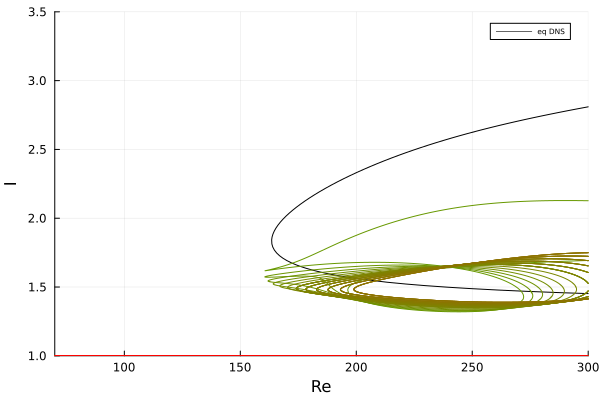

26-element Vector{Float64}:
  1.3190849888766033e-5
  0.014811322478757796
  0.0037346940877850156
  0.0009833813189457905
  0.0002841873184300121
  0.0001423554597273085
 37.083187737736345
  9.270832522990121
  2.3177437190242824
  0.5794715185306966
  ⋮
  0.00024313703951316099
  0.00014668197955118787
  0.0012509996442280737
  0.0003529171075882414
  0.00014789773329431643
  0.000991478276311309
  0.0002894340559862072
  0.00014241936575124775
  0.13679643385559376

26-element Vector{Float64}:
 4.812856353921111e-5
 0.21834893208049375
 0.05486556059775722
 0.013620968696390408
 0.0036032457470042342
 0.0010433823144948172
 0.0005310899238209943
 0.6766387717543879
 0.16929259847287637
 0.04245587778720774
 ⋮
 0.0032369494893255183
 0.0009680541849681455
 0.00053610577712549
 0.014202717692009696
 0.0036885979457211802
 0.0010772394361168512
 0.0005311517206626802
 0.6717187499331508
 0.16806255420506502

26-element Vector{Float64}:
 8.368046354527183e-5
 1.8381490460056797
 0.45955734989813674
 0.11485322254190634
 0.02914783401898262
 0.00746440790866283
 0.0021245272862400436
 0.0009552960797683268
 0.018555813623464427
 0.004888459428910995
 ⋮
 0.011329464091115396
 0.003090035050649653
 0.0011126999880531434
 0.0018427580912317749
 0.0009453387315574961
 0.36790869428600853
 0.09221396448095555
 0.02329211872615573
 0.0060691971339759745

26-element Vector{Float64}:
 0.00015674283716523256
 1.168259123348136
 0.29212298055684566
 0.07290432314424744
 0.019151936991955304
 0.005167856894997227
 0.001995966501967308
 0.006507564432606815
 0.002276783214525959
 0.0030492220640524334
 ⋮
 0.002937825204729229
 0.0019811547852230777
 0.0074087511732565964
 0.0024680393254492964
 0.0024587990439469526
 0.0024773842697671635
 0.002440627985533914
 0.002515835220046984
 0.002371906250643638

26-element Vector{Float64}:
    0.00019402503320785838
 3077.3120797627503
  769.3279867031295
  192.3318628624589
   48.08229419909336
   12.023004947489623
    3.004491858717031
    0.7514344931501838
    0.18789766603588265
    0.04548013501181082
    ⋮
    0.021271020831702334
    0.005975728099072322
    0.002454730360069328
    0.01303418381157509
    0.003971228453266224
    0.002415515442020084
    0.019071224094123915
    0.005434316388535664
    0.0023852521669855955

...

26-element Vector{Float64}:
 0.00046356301820987096
 8.264581174051552
 2.066193602348906
 0.5166307044857773
 0.12889704936541901
 0.03451600960378188
 0.011748308041802791
 0.007341596073506528
 0.013813675973660296
 0.010418072698348322
 ⋮
 0.026104363861364374
 0.011153752667140672
 0.018303491726530688
 0.00841751593066994
 0.07648800687683942
 0.02113578957954787
 0.008771454069141604
 0.01746940495403445
 0.00746791845167435

26-element Vector{Float64}:
  0.0004897394907988121
 12.87635901766051
  3.2191290089134967
  0.8048437611809285
  0.2012633820029235
  0.04816994481726789
  0.0994673409044415
  0.5118065759852684
  0.2931444092881912
  1.0539186035474497
  ⋮
  0.4706449996895473
  0.5145621953653398
  0.2139766016381962
  0.9808163135464351
  0.36967965067825675
  0.194056558772531
  1.3179094683370967
  0.5297396020765809
  0.6380782374075621

26-element Vector{Float64}:
 0.0005142492509378524
 4.474857886469859
 1.1187524574105472
 0.2797597192992654
 0.0685256256025819
 0.051165270681502374
 0.21478342996376062
 0.06902340909726389
 0.015423944618886394
 0.002294405473678613
 ⋮
 0.001019401552335155
 0.0008095844603784369
 0.0014748807211007811
 0.0007004383046492713
 0.06275054831670789
 0.015864223940346048
 0.004148719074943402
 0.0012471517176793681
 0.0007087100911571844

26-element Vector{Float64}:
   0.0005439785961029592
   3.8961813555500453
   0.9740703518152298
   0.24361734009763106
   0.06092618792969252
   0.3117567712448052
   0.0863119472618341
   0.06856728643520998
   0.02121861559350288
   0.24504024303564675
   ⋮
   0.658491622378533
   0.19508843404602522
   0.1372181067515299
   0.7671751543036629
   0.21604804959617846
   0.07658123380151251
   0.04512128715773385
   0.03905812160619251
 854.4981182476089

26-element Vector{Float64}:
     0.0005561700289739059
   466.7031420729804
   116.67577808498628
    29.168914731805902
     7.288222035604225
     5.403150933314524
     3.683743139145949
     1.8352076412927307
     4.127482053748722
     3.600787255906667
     ⋮
     7.4396932700754865
     1.4779163004239846
 26460.72336024372
  6615.22545770479
  1653.8434228362735
   413.4791999260063
   103.34650353585502
    25.728877103455716
     6.2969834907711455

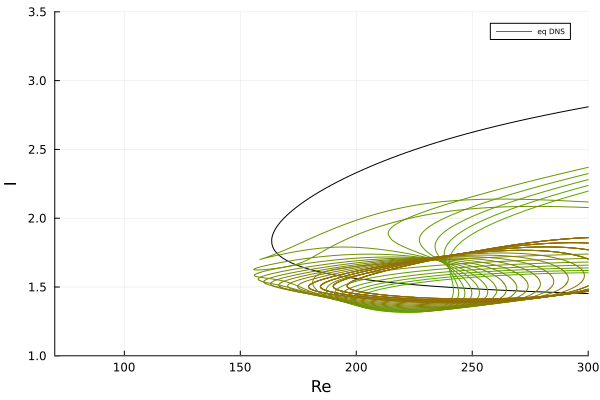

26-element Vector{Float64}:
 7.980019488873505e-6
 0.014241050074997168
 0.0035788018191713227
 0.0009173898112917053
 0.00025453226515629923
 9.900312175044793e-5
 0.00030351209711105827
 0.00010833646908587644
 0.0001686097703546926
 9.149991007058824e-5
 ⋮
 9.785529322819341e-5
 0.0003458835112253844
 0.00011731290048835958
 0.00013042987631524424
 0.00010768219529923938
 0.00017308653644285195
 9.116881695802904e-5
 0.008854263535433067
 0.0022365353158072675

26-element Vector{Float64}:
 4.450863602129322e-5
 2.958561586616325
 0.7396432347853212
 0.18495152825870817
 0.046561074478184146
 0.011585455513331563
 0.003087601078419611
 0.000914366910085979
 0.0005221553419736392
 0.009012922514190821
 ⋮
 0.0006759067603332716
 0.000708194465197505
 0.0006477812526852375
 0.0007878880266442073
 0.0005679399463035106
 0.001512756621634079
 0.0005731842242456923
 0.001402813038005833
 0.0005539098263328689

26-element Vector{Float64}:
 8.142352765627602e-5
 1.587169414679031
 0.39825188328380784
 0.10294024792221815
 0.023064554869981848
 0.008209394497328198
 0.00237329332345238
 0.0011821472909605418
 0.006447605138984369
 0.0018467565313143178
 ⋮
 0.23152398596329354
 0.05812283979378761
 0.01477637097997523
 0.003952292626923883
 0.0013064675455249377
 0.0012452343497289726
 0.0013776251280079499
 0.0011467028955073786
 0.0017979872292194414

26-element Vector{Float64}:
    0.00011920688796643046
    3.2059638984726537
    0.8014648795572192
    0.20046033128282081
    0.4264596168170054
    0.1811734440992639
    0.18742815525890907
    0.051125775394820064
   21.07134083638073
    5.270786042893898
    ⋮
    0.48620594227523467
    4.330916033732888
    1.0187718547310827
   16.70218340383516
    4.093948576984592
    1.2629512586662732
 1650.9755674114037
  413.07954899786307
  103.23840167074438

26-element Vector{Float64}:
 0.00015745837875292114
 2.8375678348300277
 0.7100525426308189
 0.17489592162278947
 0.10651669111428978
 0.05850029996096539
 1.1685166375098621
 0.28739175716096194
 0.07508757789564324
 1.5097160351261656
 ⋮
 4.955074339998261
 1.1024994755236937
 3.0847837129179645
 0.9808270973439837
 0.8608002257318
 8.775933812743858
 2.1396839153903167
 0.8530054429869387
 3.6823914450062585

...

26-element Vector{Float64}:
  0.0004748477698200634
 13.363319538938189
  3.3409883147785497
  0.8353076975270648
  0.2088739717560714
  0.050516886004848424
  0.043248612661223
  0.09583965390494706
  0.034611484450687964
  0.15330467512886783
  ⋮
  0.3220864887007127
  0.18177716896697943
  0.10584354527551078
  1.2199182542412161
  0.3367714700310944
  5.190690802543836
  2.9972708759901767
  6.091694803208404
 99.75070501148153

26-element Vector{Float64}:
    0.0005023735805142132
   40.7715732954841
   10.196340832378228
    2.5458105612240525
    0.6378726547754215
    0.15901841092103958
    0.08897724074536112
    0.06605472752379687
 1693.7021454878784
  423.36099718425055
    ⋮
    0.42873253625378854
   13.502379596018805
    3.4478918122642193
   88.71831631490609
   22.480145668047353
    5.245270474887606
    1.498140056896963
    1.9554160608790285
   55.79321951870534

26-element Vector{Float64}:
  0.0005280257019038076
 10.728608513349155
  2.682245856677915
  0.6706234369784255
  0.16757911929463798
  3.8245173369672654
  1.1315195841890284
 13.148180292966114
  4.405219967715955
  1.9540875917605618
  ⋮
  1.9677829501340869
  0.8180482476848182
  0.5201869561000446
  1.137890960482497
  0.3578066669083514
  0.7929218563455093
  1.8543253380546079
  0.6252957489923126
  5.926255376771762

26-element Vector{Float64}:
     0.0005520147642784315
     4.308521818735463
     1.0771946896223932
     0.2693773507728483
     0.06596080897397733
     1.607440282668018
     0.4027844878469809
     0.6382489309004018
     0.93328891232246
 16335.72022586568
     ⋮
     1.7277318842149885
     1.1127921395066163
   109.53508389375307
    27.375220006967652
     8.193821601206013
    48.69965065752727
    11.920809068500988
     3.039452791690067
     2.9041969211087517

26-element Vector{Float64}:
  0.0005911402253397768
 24.374438115101302
  6.093627184657979
  1.523489986848298
  0.38141328196230984
  0.09626853092151774
  0.027964521713376492
  0.6309749411054131
  0.1670507439253995
  0.036245754671256535
  ⋮
  0.8998903319126619
  0.2684604652002129
  0.2822617952714361
  0.3566190671988933
  0.4671717057505137
  1.1067548199316746
  0.43923698823984386
  0.4583584567137949
  0.294114100699405

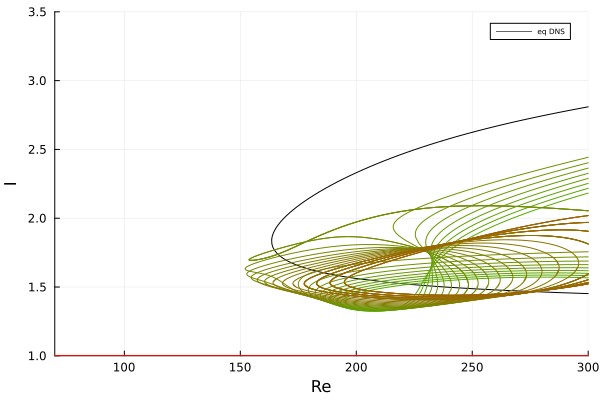

In [ ]:
#α, γ
parameters = []
minimums = []
AYErrors = []
matrix = []
minDNS = 163.5222
initialA = 1.85 #1.85
numOfTestsA = 50
rangeOfChangeInA = 1.55 #1.55
deltaA = rangeOfChangeInA/numOfTestsA
initialY = 1.3 #1.3
numOfTestsY = 37
rangeOfChangeInY = 0.9 #0.9
deltaY = rangeOfChangeInY/numOfTestsY
Re = 200 #This is supposed to be 200 you bone head
fontSize = 5

@suppress begin
    eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
    plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")

    #temp = []
    
    


    

     #α plot collecter
     for i in 0:2*rangeOfChangeInA/deltaA
        for j in 0:2*rangeOfChangeInY/deltaY
            ###DataTable((initialA - rangeOfChangeInA) + i * deltaA, (initialY - rangeOfChangeInY) + j * deltaY, Re, 0,
            ###    RGBA(0 + i * (deltaA/rangeOfChangeInA)/2, 1 - i * (deltaA/rangeOfChangeInA)/2, 0 + j * (deltaY/rangeOfChangeInY)/2, 1), fontSize);
            DataTable((initialA - rangeOfChangeInA) + i * deltaA, (initialY - rangeOfChangeInY) + j * deltaY, Re, 0,
                RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1), fontSize)#, i + 1, j + 1);
            ###display(RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1))
        end
        display(plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5)))
        savefig("α200DataSet4/α_$((initialA - rangeOfChangeInA) + i * deltaA).png")
        plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
    end
    
    
    

    #= #γ plot collecter
    for i in 0:2*rangeOfChangeInY/deltaY
        for j in 0:2*rangeOfChangeInA/deltaA
            DataTable((initialA - rangeOfChangeInA) + j * deltaA, (initialY - rangeOfChangeInY) + i * deltaY, Re, 0,
                RGBA(0 + j * (deltaA/rangeOfChangeInA)/2, 1 - j * (deltaA/rangeOfChangeInA)/2, 0, 1), fontSize);
            ###display(RGBA(0 + j * (deltaY/rangeOfChangeInY)/2, 1 - j * (deltaY/rangeOfChangeInY)/2, 0, 1))
        end
        display(plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5)))
        savefig("γ200DataSet2/γ_$((initialY - rangeOfChangeInY) + i * deltaY).png")
        plot(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
    end
    =#

    
end
#println(minimums)
#println(matrix)

#α plot collecter reshaper : γ is the y axis
matrix = Matrix{Float64}(reshape(matrix, 2 * numOfTestsY + 1,:))
writedlm("matrix_output_a_test.txt", matrix, "  ")
#=open("matrix_output_a_test.txt", "w") do file
    redirect_stdout(file) do
        show(IOContext(stdout, :limit => false), "text/plain", reshape(matrix, 2 * numOfTestsY + 1, 2 * numOfTestsA + 1)) # or just type the variable name 'matrix' in a script
    end
end=#
#store = contour((initialA - rangeOfChangeInA):deltaA:(initialA + rangeOfChangeInA), (initialY - rangeOfChangeInY):deltaY:(initialY + rangeOfChangeInY), matrix, lw=0, levels=1000, fill = true)

#show(IOContext(stdout, :limit => false), "text/plain", reshape(matrix, 2 * numOfTestsY + 1, 2 * numOfTestsA + 1))
#display(reshape(matrix, 2 * numOfTestsY + 1, 2 * numOfTestsA + 1))

#γ plot collecter reshaper : α is the y axis
#display(reshape(matrix, 2 * numOfTestsA + 1, 2 * numOfTestsY + 1))

#show(parameters[1][1])
###plot!(xlabel="Re", ylabel="I", xlim=(95,300), ylim=(1,3.5))
#push!(temp, DataTable(1.5, 2.0, 200, 1, :blue))
#temp = DataTable(1.5, 2.0, 200, 1, :blue)
#plot!(temp[1])
#plot!(temp[1][2][:,1], temp[1][2][:,2], color=temp[1][3], label="eq$(temp[1][4]) ODE, $(temp[1][5])-$(temp[1][6])-$(temp[1][7]), $(temp[1][8])d, $(temp[1][9]) x $(temp[1][10])")
#push!(temp, DataTable(1.0, 2.0, 200, 2, :red))
#temp = DataTable(1.0, 2.0, 200, 2, :red)
#plot!(temp[1])
#plot!(temp[2][2][:,1], temp[2][2][:,2], color=temp[2][3], label="eq$(temp[2][4]) ODE, $(temp[2][5])-$(temp[2][6])-$(temp[2][7]), $(temp[2][8])d, $(temp[2][9]) x $(temp[2][10])")
#plot!(temp[1][2][:,1], temp[1][2][:,2], color=temp[1][3], label="eq$(temp[1][4]) ODE, $(temp[1][5])-$(temp[1][6])-$(temp[1][7]), $(temp[1][8])d, $(temp[1][9]) x $(temp[1][10])")
#plot!(temp[2][2][:,1], temp[2][2][:,2], color=temp[2][3], label="eq$(temp[2][4]) ODE, $(temp[2][5])-$(temp[2][6])-$(temp[2][7]), $(temp[2][8])d, $(temp[2][9]) x $(temp[2][10])")

In [ ]:
for i in 10:10:500
    contour((initialA - rangeOfChangeInA):deltaA:(initialA + rangeOfChangeInA), (initialY - rangeOfChangeInY):deltaY:(initialY + rangeOfChangeInY), matrix, xlabel="a", ylabel="y", lw=0, levels=i, fill = true)
    savefig("contour2/$(i)_levels.png")
end

In [68]:
matrix = zeros(2,2)
matrixMutate(1,1,1,matrix)
show(matrix)

[1.0 0.0; 0.0 0.0]

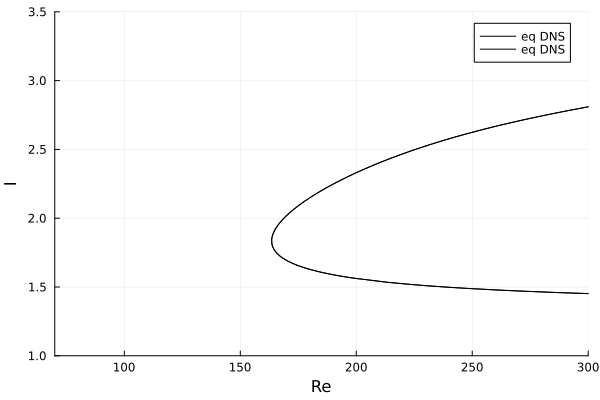

In [200]:
eq1ReD = myreaddlm("data/eq1ReD-DNS.asc", cc='#')
plot!(eq1ReD[:,1], eq1ReD[:,2], color=:black, label="eq DNS")
plot!(xlabel="Re", ylabel="I", xlim=(70,300), ylim=(1,3.5))

In [ ]:
#savefig("testing/my_plot4.png")

"c:\\Users\\cbalusek\\Desktop\\CloudAtlas\\notebooks\\testing\\my_plot4.png"

In [21]:
println("MinDNS : ", minDNS)
println("Parameters [α, γ] : ", parameters)
println("MinsOfODEs : ", minimums)
println("Error Parameters : ", AYErrors)
if length(minimums) != 0
    minIndex = findmin(minimums)[2]
    minValue = findmin(minimums)[1]
    println("Index Of Min Value : ", minIndex, ", Min Value : ", minValue, ", Parameters Of Min Value [α, γ] : [", parameters[minIndex][1], ", ", parameters[minIndex][2], "]")
end

UndefVarError: UndefVarError: `minDNS` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [59]:
for i in 1:length(minimums)
    println("Data [α, γ], Min : ", parameters[i], ", ", minimums[i])
end

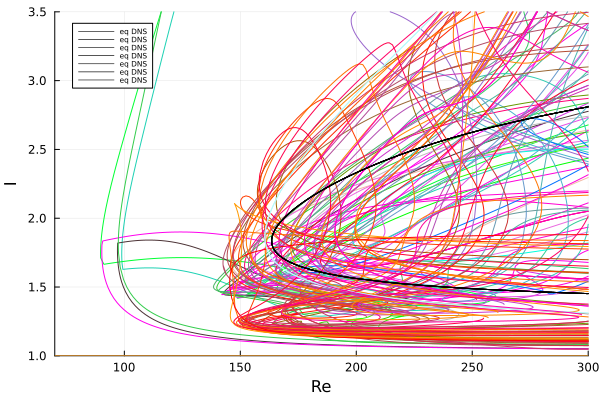

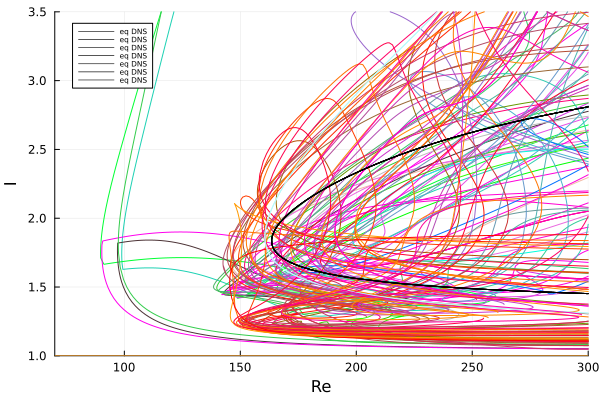

In [193]:
display(plot!())
display(plot!())